* Group by & Pivot_table
* Merge & Joins
* Melt & Pivot

In [1]:
!pip install names==0.3.0
# !pip install names --user --upgrade
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.1/789.1 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for names: filename=names-0.3.0-py3-none-any.whl size=803681 sha256=844268d332952a17d2a6ae2d68a0cc5479212d466d89bdb8418f3f03b36e61bb
  Stored in directory: /root/.cache/pip/wheels/8d/db/fc/50ec19a89a8dcbbd158a4aae44123cb525cda1f07dae287197
Successfully built names


In [ ]:
!pip install names
import pandas as pd
import numpy as np
import random
import names
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_excel('Dmart.xlsx')
df.shape
df.head(10)


,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales (shipping price included),Profit,Quantity
0,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,1205.000000,866.294118,870.294118,334.705882,-1.0,869.294118,4.0,1
1,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,320.823529,323.823529,204.411765,1.0,324.823529,3.0,1
2,2015-01-02,Moderate,Named Day,Chongqing,Chongqing,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,215.686275,142.098039,145.098039,70.588235,0.0,145.098039,3.0,1
3,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,318.823529,323.823529,204.411765,0.0,323.823529,5.0,1
4,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,137.450980,71.372549,76.372549,61.078431,1.0,77.372549,5.0,1
5,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,178.431373,116.607843,119.607843,58.823529,1.0,120.607843,3.0,1
6,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Jewellery,"Bangles, Bracelets & Armlets",216.862745,154.843137,172.843137,44.019608,1.0,173.843137,18.0,1
7,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Jewellery,"Bangles, Bracelets & Armlets",122.254902,81.941176,97.941176,24.313725,0.0,97.941176,16.0,1
8,2015-01-02,Moderate,Named Day,Chongqing,Chongqing,China,North Asia,Retail,Automotive,Car Accessories,100.588235,35.823529,53.823529,46.764706,-1.0,52.823529,18.0,1
9,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Pet Supplies,Grooming,42.156863,16.568627,21.568627,20.588235,1.0,22.568627,5.0,1


In [ ]:
# df.columns
# df = df.rename(columns={'Sales (shipping price included)': 'Sales'})
# df.groupby(by=['Region'], as_index=False)[['Profit', 'Sales']].sum().round(2)
# .to_excel('gptest12.xlsx')

# df.groupby(by=['Region'])[['Sales', 'Profit']].first()
# help(pd.core.groupby.generic.DataFrameGroup)

# df.info()
# df.sample() #return one row

# pd.DataFrame(data=[df['Shipping Cost']]).apply(lambda v: v.astype(int), axis=1).T
# df['Shipping Cost'].T == df['Shipping Cost'] # Transpose of series is same as original series.
# df['Shipping Cost'].astype(int)
# df['Order Date'].value_counts()

# pd.DatetimeIndex(df['Order Date'].unique()).isocalendar()
# df.nunique()

df[['Order Date', 'City']].drop_duplicates().sort_values(by=['Order Date', 'City']).to_excel('distinct_orddate_city.xlsx')

# Group By

In [ ]:
df.head(10)
df = df.rename(columns={'Sales (shipping price included)':'Sales'})
# print(df_t.columns)
# df_t = df.rename({'Sales (shipping price included)':'sales'}, axis='columns')
# print(df_t.columns)
# df.head()

In [ ]:
# df = pd.read_excel('Dmart.xlsx')
# df.duplicated() #returns boolean series
# df.shape[0] - (df.value_counts() > 1).shape[0]
# df[df.duplicated()]
# df.shape
# cols = [for i, c in range()]
# df[]

# pd.Series([(True if i % 2 == 0 else False) for i in range(1,len(df.columns) + 1)], index=df.columns)
# df.T[pd.Series([(True if i % 2 == 0 else False) for i in range(1,len(df.columns) + 1)], index=df.columns)].T
# df.duplicated() #duplicated is each row wise bolean series (series indexes are dataframe index and value is True/False whether
# row is duplicate or not)

# df[df.duplicated()].index
df.duplicated()


,0
0,False
1,False
2,False
3,False
4,False
...,...
6423,False
6424,False
6425,False
6426,False


In [ ]:
df.rename(columns = {'Sales (shipping price included)': 'Sales'}, inplace = True)

In [ ]:

# df.nunique() #number of unique value in each column
# df[''].nunique() #scalr value , number of unique value in the column
# if False in pd.to_datetime(df['Order Date'].value_counts().index.sort_values()) == pd.to_datetime(df['Order Date'].unique()):
#   pass
# else:
#  print('all values equal')

# b_arr = pd.to_datetime(df['Order Date'].value_counts().index.sort_values()) != pd.to_datetime(df['Order Date'].unique())

# b_arr.min()

# np.sort(df['Order Date'].value_counts().index.sort_values().to_numpy())

# df['Order Date'].unique().dtype
df['Operational/ Production Cost']==np.nan



,Operational/ Production Cost
0,False
1,False
2,False
3,False
4,False
...,...
6423,False
6424,False
6425,False
6426,False


In [ ]:
# np.array_equal(df['Order Date'].unique().to_numpy(), df['Order Date'].value_counts().index.sort_values().to_numpy())
# df['Order Date'].unique().dtype
# df['Order Date'].value_counts().index.sort_values().dtype
# df['Order Date'].unique()

np.array_equal(df['Order Date'].sort_values(), df['Order Date'][:]) #can be used for comparing the series too
np.array_equal(df['Order Date'].unique(), df['Order Date'].value_counts().index) #comparing pandas array and index feasible


False

In [ ]:
# arr = np.reshape(np.arange(0,20,1),(5,4))  #.reshape((4,5))
np.random.random((2,3))
# pd.DataFrame(data=[pd.Series([2,3,4,4,6,5]),pd.Series([6,7,8,2,1,4])]).reshape((2,6))

array([[0.11354217, 0.06181787, 0.05393878],
       [0.48284453, 0.47642056, 0.01193589]])

In [ ]:
# df.groupby('Region')['Sales'].mean()
# df.groupby(['Region', 'Segment'], as_index = False)[['Quantity', 'Sales', 'Profit']].sum()
# df.columns
# df = df.rename({'Sales (shipping price included)': 'Sales'}, axis=1)
# df.groupby(by=['Region','Segment'], as_index=False)[['Quantity', 'Sales', 'Profit']].sum()
df.groupby(by=['Region','Segment'])[['Quantity', 'Sales', 'Profit']].sum().round(0).astype(int).reset_index()

,Region,Segment,Quantity,Sales,Profit
0,Central Asia,Corporate,209,547426,91809
1,Central Asia,Retail,2744,1663401,234483
2,Central Asia,Whole Sale,139,421794,71905
3,North Asia,Corporate,238,753928,133760
4,North Asia,Retail,2653,1463735,240796
5,North Asia,Whole Sale,119,480561,94609
6,Southeast Asia,Corporate,29,70883,1362
7,Southeast Asia,Retail,309,99295,6871
8,Southeast Asia,Whole Sale,23,60696,5781


In [ ]:
df.groupby('Region')['Profit'].sum()

,Profit
Region,
Central Asia,398196.837560
North Asia,469164.818510
Southeast Asia,14014.170973


In [ ]:
df.groupby(['Region', 'Segment'])['Quantity'].sum() # pd.Series

Region          Segment   
Central Asia    Corporate      209
                Retail        2744
                Whole Sale     139
North Asia      Corporate      238
                Retail        2653
                Whole Sale     119
Southeast Asia  Corporate       29
                Retail         309
                Whole Sale      23
Name: Quantity, dtype: int64

In [ ]:
df.groupby(['Region', 'Segment'], as_index = False)['Quantity'].sum()

,Region,Segment,Quantity
0,Central Asia,Corporate,209
1,Central Asia,Retail,2744
2,Central Asia,Whole Sale,139
3,North Asia,Corporate,238
4,North Asia,Retail,2653
5,North Asia,Whole Sale,119
6,Southeast Asia,Corporate,29
7,Southeast Asia,Retail,309
8,Southeast Asia,Whole Sale,23


In [ ]:
df.groupby(['Region', 'Segment'], as_index = False)[['Quantity', 'Sales', 'Profit']].sum()

,Region,Segment,Quantity,Sales,Profit
0,Central Asia,Corporate,209,5.474258e+05,91808.532950
1,Central Asia,Retail,2744,1.663401e+06,234482.956220
2,Central Asia,Whole Sale,139,4.217944e+05,71905.348390
3,North Asia,Corporate,238,7.539277e+05,133760.235460
4,North Asia,Retail,2653,1.463735e+06,240795.681280
5,North Asia,Whole Sale,119,4.805613e+05,94608.901770
6,Southeast Asia,Corporate,29,7.088325e+04,1361.715633
7,Southeast Asia,Retail,309,9.929538e+04,6871.082618
8,Southeast Asia,Whole Sale,23,6.069631e+04,5781.372722


In [ ]:
df.groupby('Region', as_index = False).agg(Sum_Qty = ('Quantity', 'sum'), Max_Sales = ('Sales', 'max'), Mean_profit = ('Profit', 'mean'))

,Region,Sum_Qty,Max_Sales,Mean_profit
0,Central Asia,3092,42854.8639,129.117003
1,North Asia,3010,42305.0696,157.279523
2,Southeast Asia,361,11331.7351,38.820418


In [ ]:
df.groupby('Region')['Profit'].mean()
# np.mean(pd.Series([2,5,4,8,9]))
# pd.Series([2,3,4,6]).mean()

5.6

In [ ]:
df.groupby('Region')['Profit'].min()

Region
Central Asia     -4476.44580
North Asia       -7698.94280
Southeast Asia   -4157.95346
Name: Profit, dtype: float64

In [ ]:
df.groupby('Region')['Profit'].max()

Region
Central Asia      19747.0999
North Asia        11229.9499
Southeast Asia     2656.2292
Name: Profit, dtype: float64

In [ ]:
df.groupby('Region')['Profit'].std()

Region
Central Asia      702.894338
North Asia        715.461717
Southeast Asia    416.929907
Name: Profit, dtype: float64

In [ ]:
# df.groupby('Region')['Profit'].var()
df.sample(10)

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales,Profit,Quantity
128,2015-02-02,High,Next Day,Yunyang,Henan,China,North Asia,Corporate,Office Supplies,Storage,2676.978800,1956.491000,2676.978800,0.000000,612.8142,3289.793000,720.4878,1
6125,2018-11-09,Low,Standard Delivery,Lianzhou,Guangxi,China,North Asia,Retail,Clothing,Women's Clothing,91.274510,NaN,63.431373,27.843137,1.0000,64.431373,1.0000,1
2613,2016-12-11,Moderate,Named Day,Bangalore,Karnataka,India,Central Asia,Retail,Technology,Accessories,2936.489000,2064.795500,2929.479000,7.010000,175.2500,3097.719000,864.6835,1
3720,2017-08-07,Low,Standard Delivery,Darbhanga,Bihar,India,Central Asia,Corporate,Furniture,Furnishings,4920.038600,3459.575200,4920.038600,0.000000,386.4613,5306.499900,1460.4634,1
3697,2017-08-07,Low,Standard Delivery,Darbhanga,Bihar,India,Central Asia,Retail,Jewellery,"Bangles, Bracelets & Armlets",92.843137,46.725490,63.725490,29.117647,2.0000,65.725490,17.0000,1
1462,2016-01-11,High,Next Day,Jinan,Shandong,China,North Asia,Retail,Jewellery,"Bangles, Bracelets & Armlets",131.372549,80.549020,97.549020,33.823529,2.0000,99.549020,17.0000,1
1090,2015-08-10,Low,Standard Delivery,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Furniture,Furnishings,573.277800,361.295400,566.267800,7.010000,51.5936,610.851400,204.9724,1
938,2015-07-10,High,Next Day,Qingdao,Shandong,China,North Asia,Retail,Clothing,Women's Clothing,110.098039,NaN,73.431373,36.666667,1.0000,74.431373,2.0000,1
5966,2018-10-06,Moderate,Named Day,Liuyang,Hunan,China,North Asia,Retail,Home Entertainment,Video Players & Accessories,1655.882353,864.372549,881.372549,774.509804,-1.0000,880.372549,17.0000,1
1022,2015-08-08,Extreme,Same Day,Guangzhou,Guangdong,China,North Asia,Retail,Jewellery,Necklaces & Chains,35.196078,3.607843,19.607843,15.588235,2.0000,21.607843,16.0000,1


# Pivot_Table

In [ ]:
# df.pivot_table(index = , column = , values = , aggfunc = mean)
# df.columns
# df.groupby(by=['Segment'])[['Sales']].sum().round(0).reset_index().pivot(values='Sales', columns='Segment')
# .pivot(columns=['Segment'], index=['Order Date'])
# ?df.pivot_table
df.pivot_table(index='Region', columns='Segment', values=['Sales', 'Profit'], aggfunc=['sum','mean'], margins=True).round(2)
df.pivot_table(index='Region', columns='Segment', values=['Sales', 'Profit'], aggfunc=['sum', 'mean'], margins=True).round(0)

sum                                                       \
                  Profit                                     Sales              
Segment        Corporate    Retail Whole Sale       All  Corporate     Retail   
Region                                                                          
Central Asia     91809.0  234483.0    71905.0  398197.0   547426.0  1663401.0   
North Asia      133760.0  240796.0    94609.0  469165.0   753928.0  1463735.0   
Southeast Asia    1362.0    6871.0     5781.0   14014.0    70883.0    99295.0   
All             226930.0  482150.0   172296.0  881376.0  1372237.0  3226431.0   

                                          mean                           \
                                        Profit                            
Segment        Whole Sale        All Corporate Retail Whole Sale    All   
Region                                                                    
Central Asia     421794.0  2632621.0     446.0   86.0      517.0  129.0   
North Asia       480561.0  2698224.0     572.0   91.0      823.0  157.0   
Southeast Asia    60696.0   230875.0      47.0   22.0      251.0   39.0   
All              963052.0  5561720.0     484.0   85.0      622.0  137.0   

                                                   
                   Sales                           
Segment        Corporate Retail Whole Sale    All  
Region                                             
Central Asia      2657.0  607.0     3034.0  854.0  
North Asia        3222.0  556.0     4179.0  905.0  
Southeast Asia    2444.0  321.0     2639.0  640.0  
All               2926.0  568.0     3477.0  865.0

In [ ]:
df.pivot_table(index='Region', columns='Segment', values=['Sales', 'Profit'], aggfunc=['sum','mean'], margins=True)


NameError: name 'df' is not defined

In [ ]:
# df.pivot_table(index = 'Region', columns = 'Segment' , values = 'Sales')
df = df.rename({'Sales (shipping price included)': 'Sales'}, axis=1)
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales', 'Profit', 'Quantity'],
      dtype='object')

In [ ]:
df.pivot_table(index = 'Region', columns = 'Segment', values = 'Sales', aggfunc = 'sum')

Segment,Corporate,Retail,Whole Sale
Region,,,
Central Asia,547425.796250,1.663401e+06,421794.426890
North Asia,753927.715160,1.463735e+06,480561.345870
Southeast Asia,70883.250433,9.929538e+04,60696.310722


In [ ]:
df.pivot_table(index = 'Region', columns = 'Segment', values = 'Sales', aggfunc = 'sum', margins = True).round(2)

Segment,Corporate,Retail,Whole Sale,All
Region,,,,
Central Asia,547425.80,1663400.90,421794.43,2632621.12
North Asia,753927.72,1463735.07,480561.35,2698224.13
Southeast Asia,70883.25,99295.38,60696.31,230874.94
All,1372236.76,3226431.35,963052.08,5561720.19


In [ ]:
df.pivot_table(index = 'Region', columns = 'Segment' , values = ['Sales', 'Profit'], aggfunc = ['sum','mean']).round(2)

sum                                               \
                   Profit                            Sales               
Segment         Corporate     Retail Whole Sale  Corporate      Retail   
Region                                                                   
Central Asia     91808.53  234482.96   71905.35  547425.80  1663400.90   
North Asia      133760.24  240795.68   94608.90  753927.72  1463735.07   
Southeast Asia    1361.72    6871.08    5781.37   70883.25    99295.38   

                               mean                                      \
                             Profit                       Sales           
Segment        Whole Sale Corporate Retail Whole Sale Corporate  Retail   
Region                                                                    
Central Asia    421794.43    445.67  85.61     517.30   2657.41  607.30   
North Asia      480561.35    571.62  91.42     822.69   3221.91  555.71   
Southeast Asia   60696.31     46.96  22.24     251.36   2444.25  321.34   

                           
                           
Segment        Whole Sale  
Region                     
Central Asia      3034.49  
North Asia        4178.79  
Southeast Asia    2638.97

# Merge and Joins
* Merge - Traditional SQL Joins - Joins table based on common columns
* Join - Joins table based on common indexes

In [ ]:
df1 = pd.DataFrame({"Student" : list('ABCDE'), 'Age' : [11,12,13,14,15]})
df2 = pd.DataFrame({"Student" : list('ABC'), 'Rank' : [5,4,1]})
df3 = pd.DataFrame({'Maths' : [34,35,36,37,38,39,40], 'Chemistry' : [56,57,58,59,60,61,62]})

In [ ]:
df1

,Student,Age
0,A,11
1,B,12
2,C,13
3,D,14
4,E,15


In [ ]:
df2

,Student,Rank
0,A,5
1,B,4
2,C,1


In [ ]:
# df1.merge(df2, on = 'Student', how = 'inner')
df1.merge(df2, on='Student', how='inner')

,Student,Age,Rank
0,A,11,5
1,B,12,4
2,C,13,1


In [ ]:
df1.merge(df2, on = 'Student', how = 'left')

,Student,Age,Rank
0,A,11,5.0
1,B,12,4.0
2,C,13,1.0
3,D,14,NaN
4,E,15,NaN


In [ ]:
df1.merge(df2, on = 'Student', how = 'right')

,Student,Age,Rank
0,A,11,5
1,B,12,4
2,C,13,1


In [ ]:
df1.merge(df2, on = 'Student', how = 'outer') # Full Join

,Student,Age,Rank
0,A,11,5.0
1,B,12,4.0
2,C,13,1.0
3,D,14,NaN
4,E,15,NaN


In [ ]:
df1.merge(df2, left_on = 'Student', right_on = 'Student', how = 'inner').sort_values(by = 'Student', ascending = False)

,Student,Age,Rank
2,C,13,1
1,B,12,4
0,A,11,5


# JOIN

In [ ]:
df1

,Student,Age
0,A,11
1,B,12
2,C,13
3,D,14
4,E,15


In [ ]:
df3

,Maths,Chemistry
0,34,56
1,35,57
2,36,58
3,37,59
4,38,60
5,39,61
6,40,62


In [ ]:
df1.join(df3, how = 'inner')

,Student,Age,Maths,Chemistry
0,A,11,34,56
1,B,12,35,57
2,C,13,36,58
3,D,14,37,59
4,E,15,38,60


In [ ]:
df1.join(df3, how = 'left')

NameError: name 'df1' is not defined

In [ ]:
df1.join(df3, how = 'right')

,Student,Age,Maths,Chemistry
0,A,11.0,34,56
1,B,12.0,35,57
2,C,13.0,36,58
3,D,14.0,37,59
4,E,15.0,38,60
5,NaN,NaN,39,61
6,NaN,NaN,40,62


In [ ]:
df1.join(df3, how = 'outer') # full join

,Student,Age,Maths,Chemistry
0,A,11.0,34,56
1,B,12.0,35,57
2,C,13.0,36,58
3,D,14.0,37,59
4,E,15.0,38,60
5,NaN,NaN,39,61
6,NaN,NaN,40,62


# Melt & Pivot
* Melt - Increasing the number of rows by transposing columns
* Pivot - Increasing the nuber of columns by transposing rows

In [ ]:
dfs = pd.DataFrame({'Sales Rep' : ['Raj', 'Govind', 'Raghav', 'Sri', 'Gow'],
                    'Jan' : [10,20,30,40,50], 'Feb' : [20,40,60,80,100],
                    'Mar' : [100,90,80,70,60], 'Apr' : [12,34,56,78,90]})
dfs

,Sales Rep,Jan,Feb,Mar,Apr
0,Raj,10,20,100,12
1,Govind,20,40,90,34
2,Raghav,30,60,80,56
3,Sri,40,80,70,78
4,Gow,50,100,60,90


In [ ]:
dfs.groupby(by='Sales Rep')

In [ ]:
dfs.melt(id_vars='Sales Rep', value_vars=['Jan', 'Feb', 'Mar'], var_name='Month', value_name='Sales')

,Sales Rep,Month,Sales
0,Raj,Jan,10
1,Govind,Jan,20
2,Raghav,Jan,30
3,Sri,Jan,40
4,Gow,Jan,50
5,Raj,Feb,20
6,Govind,Feb,40
7,Raghav,Feb,60
8,Sri,Feb,80
9,Gow,Feb,100


In [ ]:
dfs.groupby('Sales Rep', as_index=False)[['Jan', 'Feb']].sum()

,Sales Rep,Jan,Feb
0,Govind,20,40
1,Gow,50,100
2,Raghav,30,60
3,Raj,10,20
4,Sri,40,80


In [ ]:
dfs.melt(id_vars = 'Sales Rep', value_vars = ['Jan', 'Feb', 'Mar', 'Apr'])

,Sales Rep,variable,value
0,Raj,Jan,10
1,Govind,Jan,20
2,Raghav,Jan,30
3,Sri,Jan,40
4,Gow,Jan,50
5,Raj,Feb,20
6,Govind,Feb,40
7,Raghav,Feb,60
8,Sri,Feb,80
9,Gow,Feb,100


In [ ]:
dfs_melted = dfs.melt(id_vars = 'Sales Rep', value_vars = ['Jan', 'Feb', 'Mar', 'Apr'], var_name = 'Month', value_name = 'Sales')
dfs_melted

,Sales Rep,Month,Sales
0,Raj,Jan,10
1,Govind,Jan,20
2,Raghav,Jan,30
3,Sri,Jan,40
4,Gow,Jan,50
5,Raj,Feb,20
6,Govind,Feb,40
7,Raghav,Feb,60
8,Sri,Feb,80
9,Gow,Feb,100


In [ ]:
dfs_melted.groupby('Sales Rep')['Sales'].sum()

,Sales
Sales Rep,
Govind,184
Gow,300
Raghav,226
Raj,142
Sri,268


In [ ]:
dfs_melted.pivot(index = 'Sales Rep', columns = 'Month', values='Sales')

Month,Apr,Feb,Jan,Mar
Sales Rep,,,,
Govind,34,40,20,90
Gow,90,100,50,60
Raghav,56,60,30,80
Raj,12,20,10,100
Sri,78,80,40,70


# Matplotlib

In [ ]:
# from matplot import pyplot as plt
import matplotlib.pyplot as plt


### Top 10 Cities by Sales

In [ ]:
df.groupby('City')['Sales'].sum()

KeyError: 'Column not found: Sales'

In [ ]:
df = pd.read_excel('Dmart.xlsx')
# df = df.rename({'Sales (shipping price included)': 'Sales'}, axis=1)

FileNotFoundError: [Errno 2] No such file or directory: 'Dmart.xlsx'

In [ ]:
# df.groupby('City', as_index = False)['Sales'].sum()
# df.groupby(by=['City'], as_index=False)['Sales'].sum().sort_values(by=['Sales', 'City'], ascending=[False, True]).reset_index(drop=True)[:10]
# help(df.sort_values)
# df.loc[1,['Order Date']]
# def check_null
# df.where(df['City'].str.startswith('A')).dropna(how='all', axis=0)
# df['City'] == 'Dhaka'

# df[~df['City'].str.startswith('A')]

# df[:2].eq(df[:2]) # boolean df with respective rows and columns

# np.equal(df[0:2], df[:2]) # boolean df with respective rows and columns
np.array_equal(df['Order Date'], df['Quantity']) # True/False
# in DF indexing :
# providing STRING/INT (scalar or list or series or NDArray) comparing to columns (if int , column index)
# providing BOOLEAN series or array comparing with index(or rows)

# dft['score1']
# df.T[1:].duplicated()
# df[-2:].reset_index()
# 'a'.startswith('a')

False

In [ ]:
df[:2]

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales (shipping price included),Profit,Quantity
0,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,1205.000000,866.294118,870.294118,334.705882,-1.0,869.294118,4.0,1
1,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,320.823529,323.823529,204.411765,1.0,324.823529,3.0,1


In [ ]:
df[-2:]

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales (shipping price included),Profit,Quantity
6426,2018-12-12,Moderate,Named Day,Dalian,Liaoning,China,North Asia,Retail,Technology,Phones,948.1726,736.050,948.1726,0.00,104.1686,1052.3412,212.1226,1
6427,2018-12-12,High,Next Day,Shuangyashan,Heilongjiang,China,North Asia,Retail,Office Supplies,Storage,1741.9850,1471.399,1734.9750,7.01,356.0379,2084.0029,263.5760,1


In [ ]:
df.groupby('City', as_index=False)['Sales'].sum().sort_values(by='Sales', ascending=False)

,City,Sales
197,Shanghai,172090.212575
56,Dhaka,165180.436843
54,Delhi,160275.315473
219,Suzhou,144554.442282
211,Singapore,118592.295555
...,...,...
206,Shizuishan,511.087416
80,Huadian,504.013039
44,Chifeng,459.208029
237,Ujjain,378.646490


In [ ]:
df.groupby('City', as_index = False)['Sales'].sum().sort_values(by = 'Sales', ascending = False)[:10]


KeyError: 'Column not found: Sales'

In [ ]:
# df.groupby('City', as_index = False)['Sales'].sum().sort_values(by = 'Sales', ascending = False)[:10].reset_index()
df.rename({'Sales (shipping price included)': 'Sales'})

,Order Date,Order Priority,Ship Type,City,State,Country,Region,Segment,Super Category,Category,Price,Operational/ Production Cost,Selling Price,Discount,Shipping Cost,Sales (shipping price included),Profit,Quantity
0,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,1205.000000,866.294118,870.294118,334.705882,-1.0000,869.294118,4.0000,1
1,2015-01-02,Moderate,Named Day,Yingcheng,Hubei,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,320.823529,323.823529,204.411765,1.0000,324.823529,3.0000,1
2,2015-01-02,Moderate,Named Day,Chongqing,Chongqing,China,North Asia,Retail,Baby Care,Baby & Kids Gifts,215.686275,142.098039,145.098039,70.588235,0.0000,145.098039,3.0000,1
3,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,528.235294,318.823529,323.823529,204.411765,0.0000,323.823529,5.0000,1
4,2015-01-02,Moderate,Named Day,Dhaka,Dhaka,Bangladesh,Central Asia,Retail,Baby Care,Baby & Kids Gifts,137.450980,71.372549,76.372549,61.078431,1.0000,77.372549,5.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6423,2018-12-12,High,Next Day,Shuangyashan,Heilongjiang,China,North Asia,Retail,Furniture,Furnishings,340.125200,162.912400,340.125200,0.000000,64.9827,405.107900,177.2128,1
6424,2018-12-12,Low,Standard Delivery,Huaiyin,Jiangsu,China,North Asia,Whole Sale,Furniture,Furnishings,808.253000,719.366200,808.253000,0.000000,59.6551,867.908100,88.8868,1
6425,2018-12-12,Low,Standard Delivery,Hangzhou,Zhejiang,China,North Asia,Whole Sale,Office Supplies,Paper,410.505600,378.189500,403.495600,7.010000,10.4449,406.930500,25.3061,1
6426,2018-12-12,Moderate,Named Day,Dalian,Liaoning,China,North Asia,Retail,Technology,Phones,948.172600,736.050000,948.172600,0.000000,104.1686,1052.341200,212.1226,1


In [ ]:
top10cities = df.groupby('City', as_index = False)['Sales'].sum().\
                sort_values(by = 'Sales', ascending = False)[:10].\
                reset_index(drop = True).round(2)
top10cities

,City,Sales
0,Shanghai,172090.21
1,Dhaka,165180.44
2,Delhi,160275.32
3,Suzhou,144554.44
4,Singapore,118592.30
5,Yangon,112282.65
6,Guangzhou,112161.36
7,Gorakhpur,100305.08
8,Shenzhen,84935.70
9,Lahore,79200.81


In [ ]:
df = df.rename({'Sales (shipping price included)': 'Sales'}, axis=1)
# df.columns
# df = pd.read_excel('Dmart.xlsx')

# Line Chart

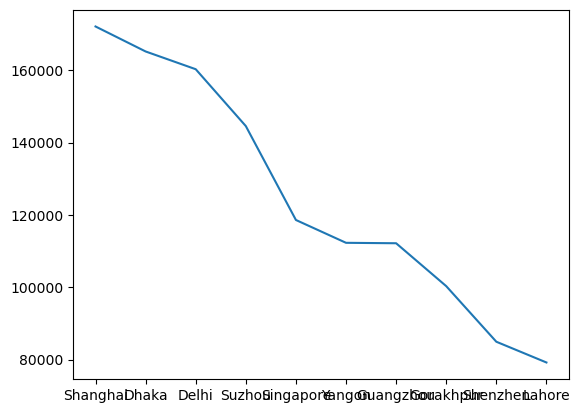

In [ ]:
plt.plot(top10cities['City'], top10cities['Sales']) # x-axis, y-axis

In [ ]:
city, sales = top10cities['City'], top10cities['Sales']

In [ ]:
city

0     Shanghai
1        Dhaka
2        Delhi
3       Suzhou
4    Singapore
5       Yangon
6    Guangzhou
7    Gorakhpur
8     Shenzhen
9       Lahore
Name: City, dtype: object

In [ ]:
sales

0    172090.21
1    165180.44
2    160275.32
3    144554.44
4    118592.30
5    112282.65
6    112161.36
7    100305.08
8     84935.70
9     79200.81
Name: Sales, dtype: float64

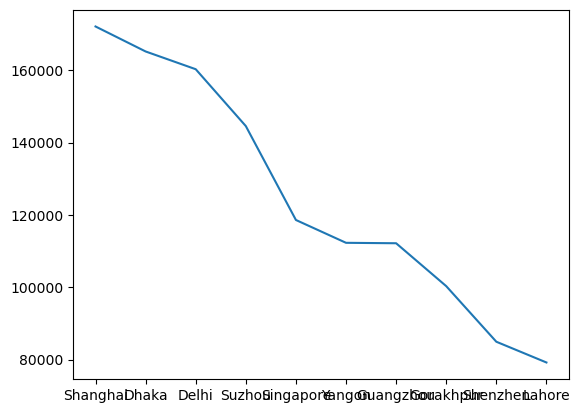

In [ ]:
plt.plot(city, sales); # using semi-colon at the last line will suppress the object address

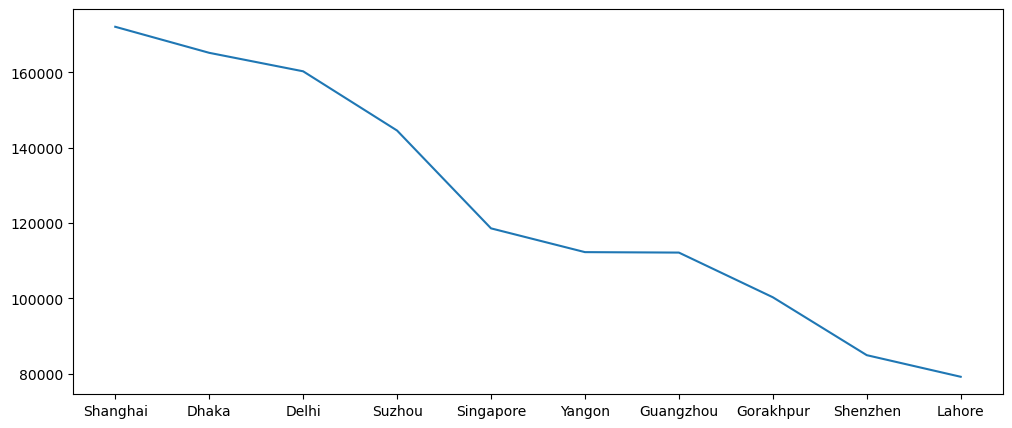

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.plot(city, sales);

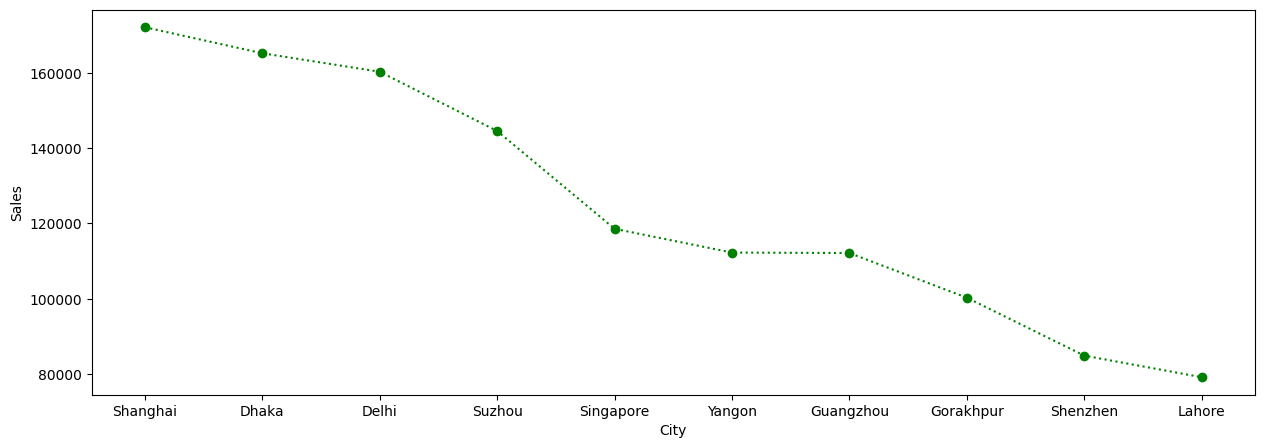

In [ ]:
plt.figure(figsize=(15,5))
plt.ylabel('Sales')
plt.xlabel('City')
plt.plot(city, sales, 'g:o')


In [ ]:
# k - black, w - white, r - red, y - yellow, m - magenta, c - cyan, b - blue, g - green
# orange

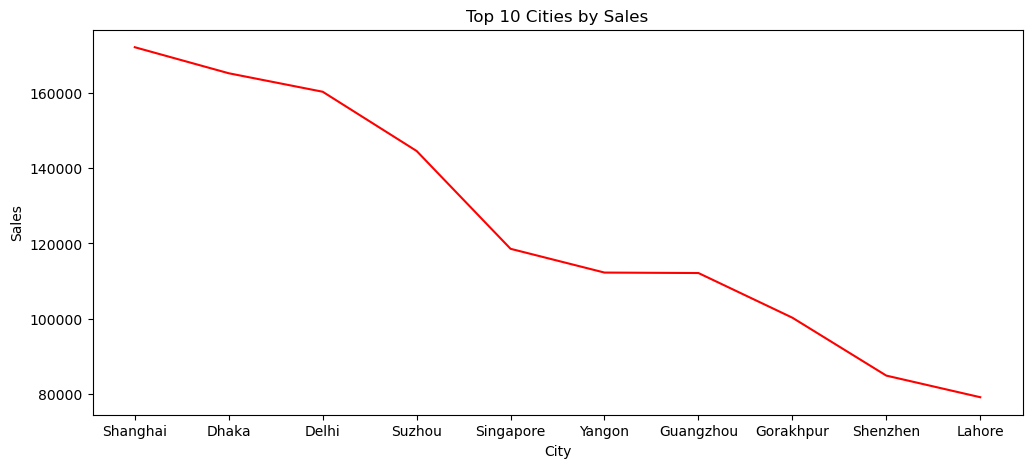

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'r') # x, y, color
plt.xlabel('City')
plt.ylabel('Sales');

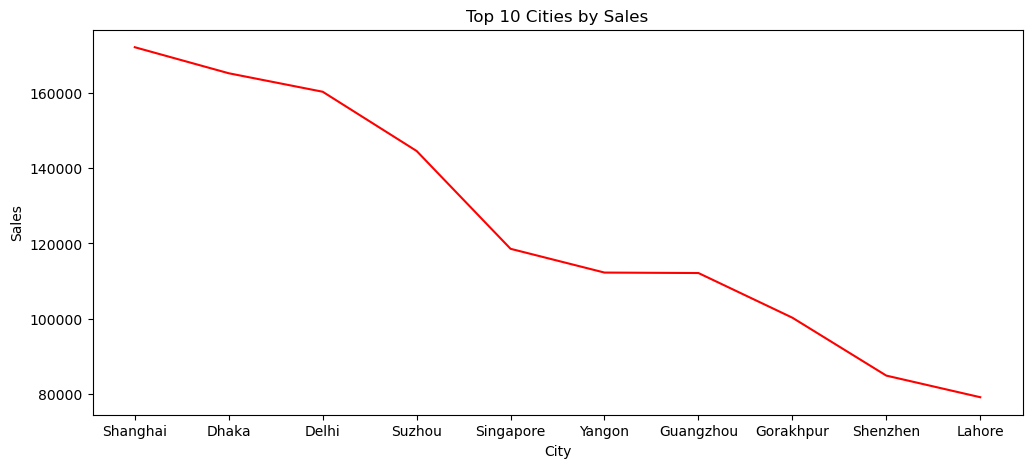

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'red') # x, y, color
plt.xlabel('City')
plt.ylabel('Sales');

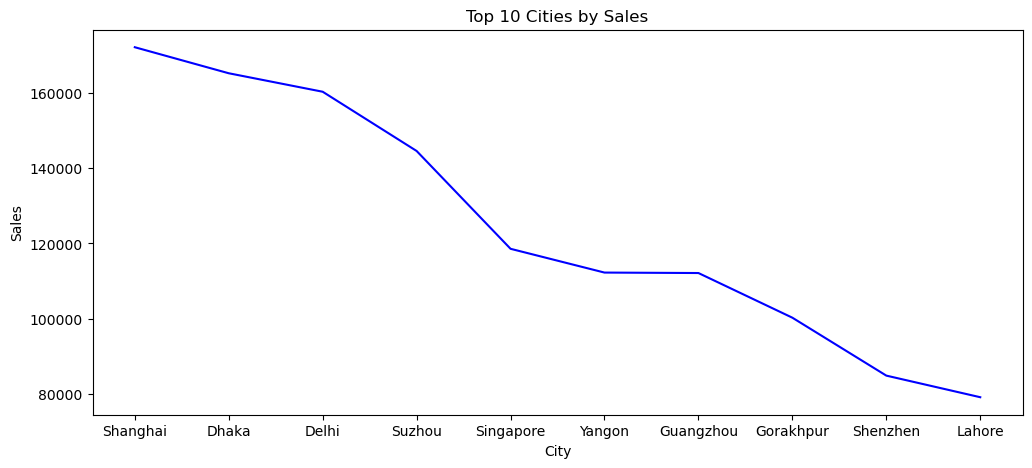

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'b') # x, y, color
plt.xlabel('City')
plt.ylabel('Sales');

In [ ]:
# --, --o, o, d - diamond, s - square, ^ - triangle, >, <, v, --., ., *
import matplotlib.pyplot as plt
?plt.plot

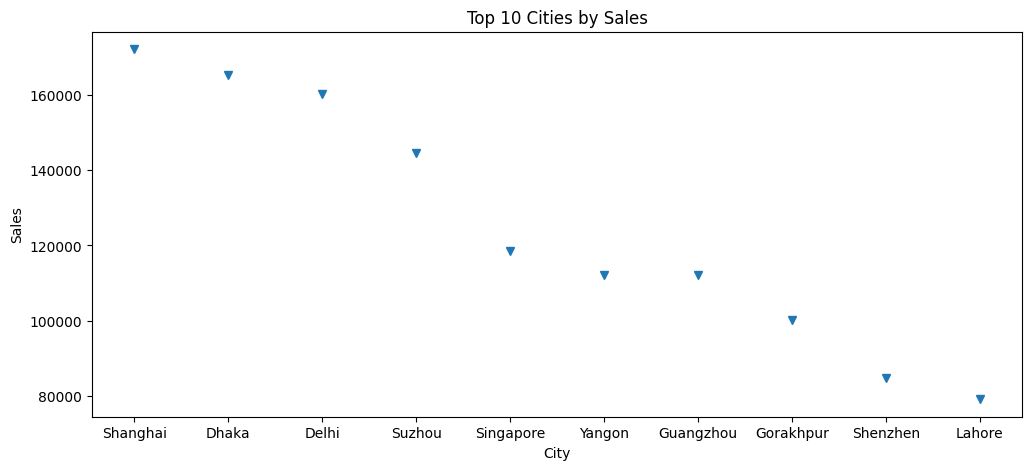

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
# plt.plot(city, sales, color='r', linestyle='dotted') # x, y, color & marker
plt.plot(city, sales, 'v')
plt.xlabel('City')
plt.ylabel('Sales');

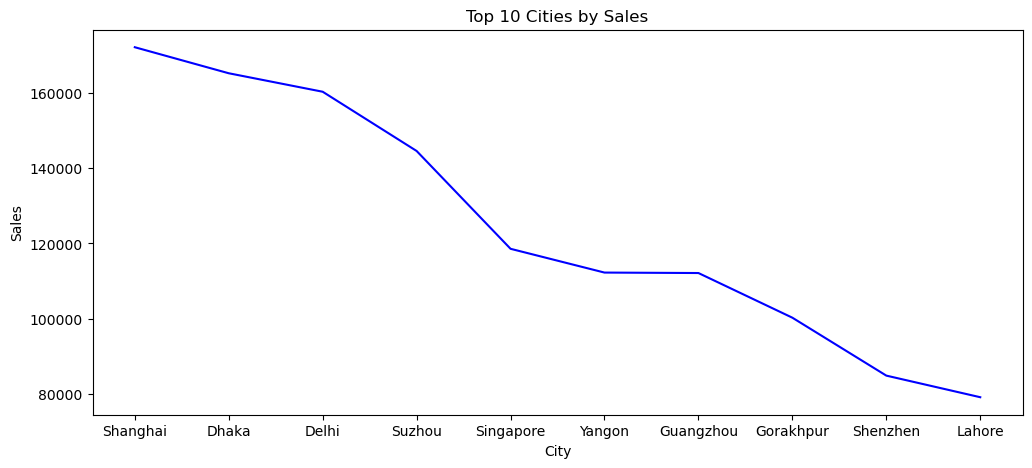

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'b-') # x, y, color & marker
plt.xlabel('City')
plt.ylabel('Sales');

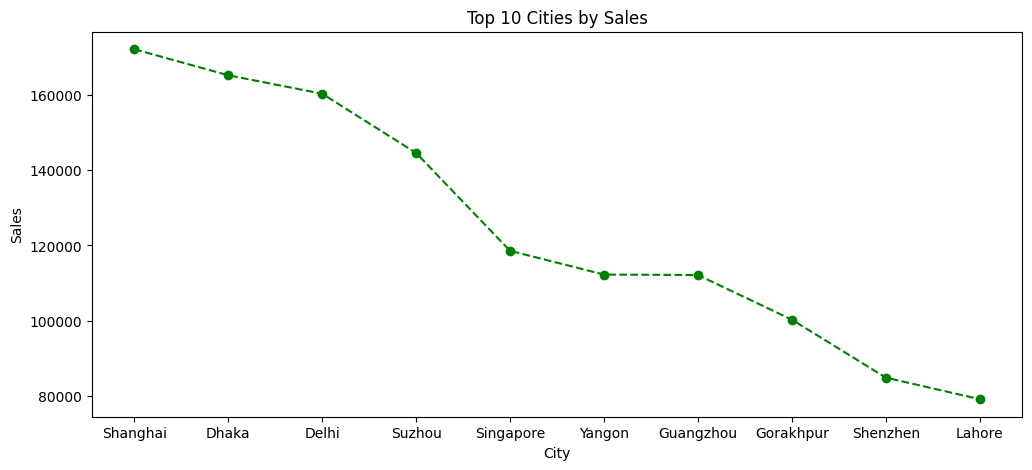

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'g--o') # x, y, color linestyle marker
plt.xlabel('City')
plt.ylabel('Sales');

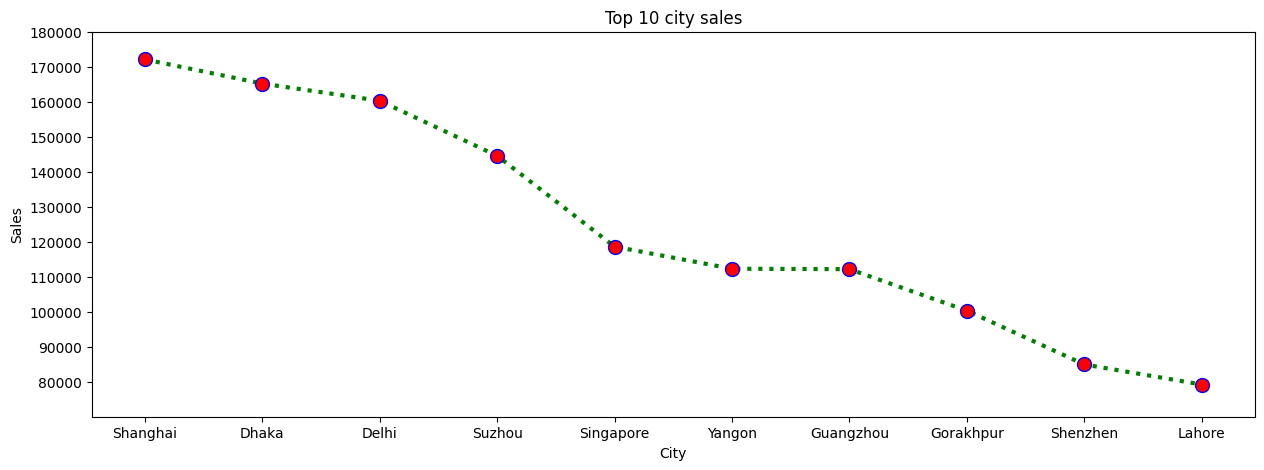

In [ ]:
# plt.figure(figsize = (12, 5)) # width, height
# plt.title('Top 10 Cities by Sales')
# # mec = markeredgecolor, mfc = markerfacecolor
# plt.plot(city, sales, 'g--o', mec = 'b', mfc = 'r')
# plt.xlabel('City')
# plt.ylabel('Sales');


plt.figure(figsize=(15,5))
plt.ylabel('Sales')
plt.xlabel('City')
plt.title('Top 10 city sales')
plt.plot(city, sales, 'go', mec='b', mfc='r', ms=10, lw=3, ls=':') # ls = '--'
plt.ylim(70000, 180000)
plt.yticks(range(80000, 180001, 10000))
plt.show()
# plt.savefig('matplot example.gif', dpi=)

In [ ]:
?plt.yticks

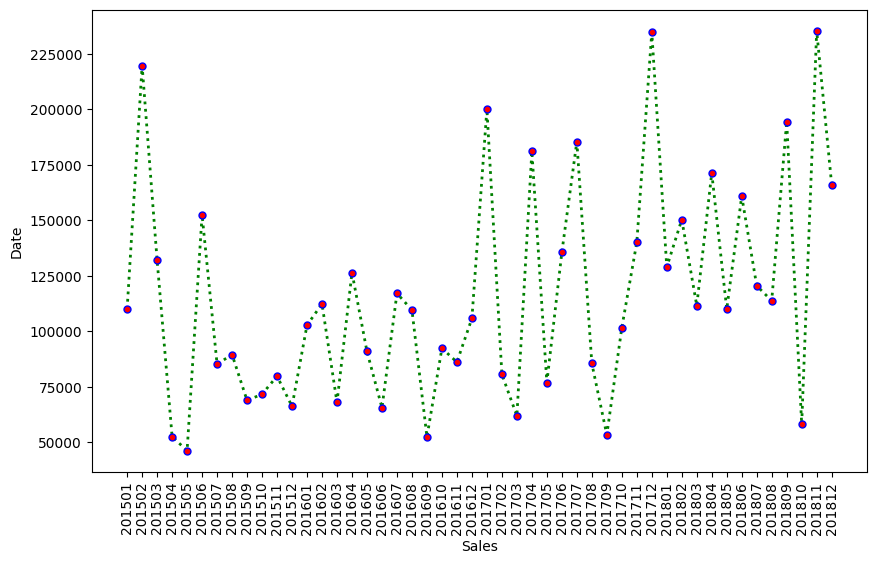

In [ ]:
# df = pd.read_excel('Dmart.xlsx')
# df.sample(10)
# df.columns
# df = df.rename(columns={'Sales (shipping price included)': 'Sales'})
# df.info()
# df.dtypes
# pd.DatetimeIndex(df['Order Date'])

dfs = df.groupby(by=(pd.DatetimeIndex(df['Order Date']).year.astype(str).str[:]) + ('0'+pd.DatetimeIndex(df['Order Date']).month.astype(str)).str[-2:],)[['Sales', 'Profit']].sum().reset_index()
plt.figure(figsize=(10,6))
plt.xlabel('Sales')
plt.ylabel('Date')
plt.xticks(rotation='vertical')
# plt.plot(dfs['Order Date'], dfs['Profit'], 'g-o', ms=5, mfc='r', mec='b', lw=3)
plt.plot(dfs['Order Date'], dfs['Sales'], 'g:o', ms=5, lw=2, mec='b', mfc='r' )


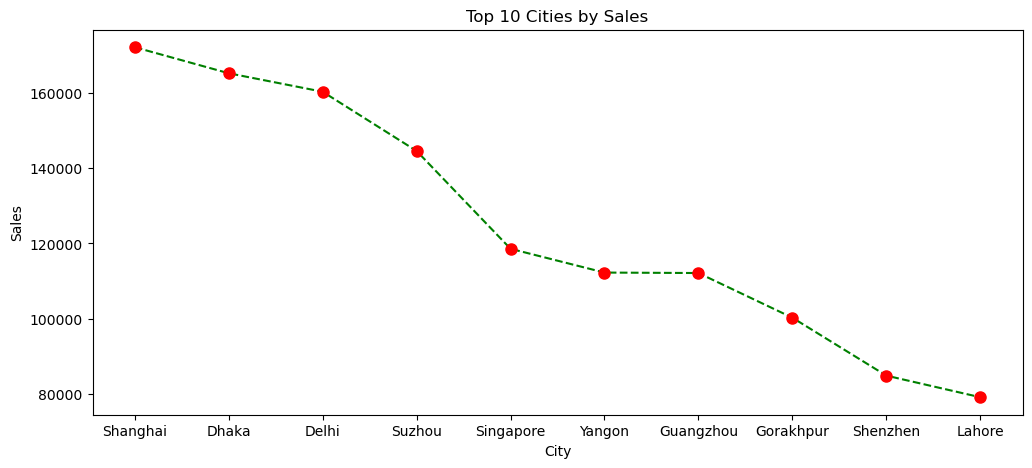

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
# mec = markeredgecolor, mfc = markerfacecolor, ms = markersize
plt.plot(city, sales, 'g--o', mec = 'r', mfc = 'r', ms = 8)
plt.xlabel('City')
plt.ylabel('Sales');

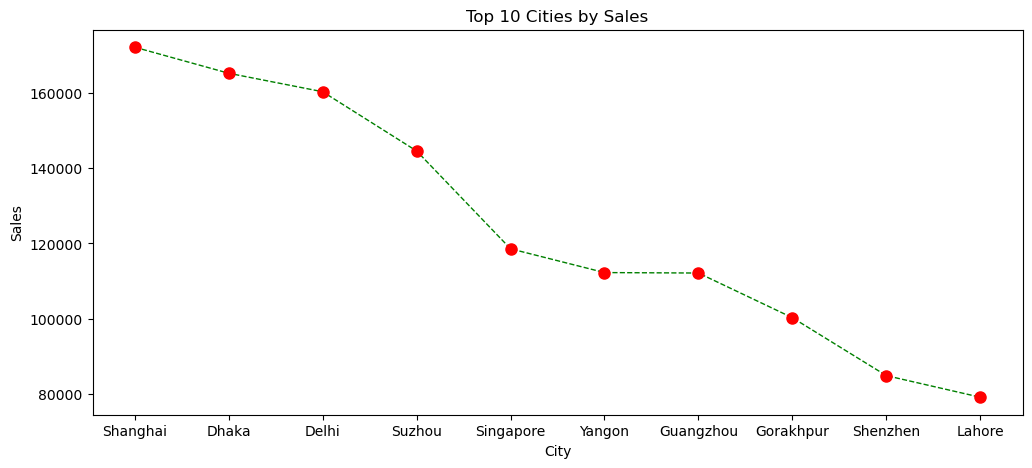

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
# mec = markeredgecolor, mfc = markerfacecolor, ms = markersize, lw = linewidth
plt.plot(city, sales, 'g--o', mec = 'r', mfc = 'r', ms = 8, lw = 1)
plt.xlabel('City')
plt.ylabel('Sales');

In [ ]:
sales

0    172090.21
1    165180.44
2    160275.32
3    144554.44
4    118592.30
5    112282.65
6    112161.36
7    100305.08
8     84935.70
9     79200.81
Name: Sales, dtype: float64

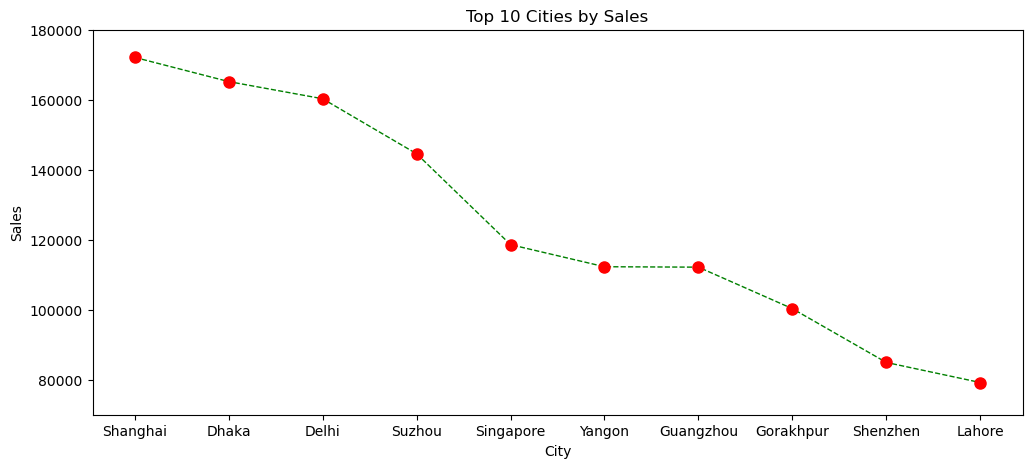

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'g--o', mec = 'r', mfc = 'r', ms = 8, lw = 1)
plt.ylim(70000, 180000)
plt.xlabel('City')
plt.ylabel('Sales');

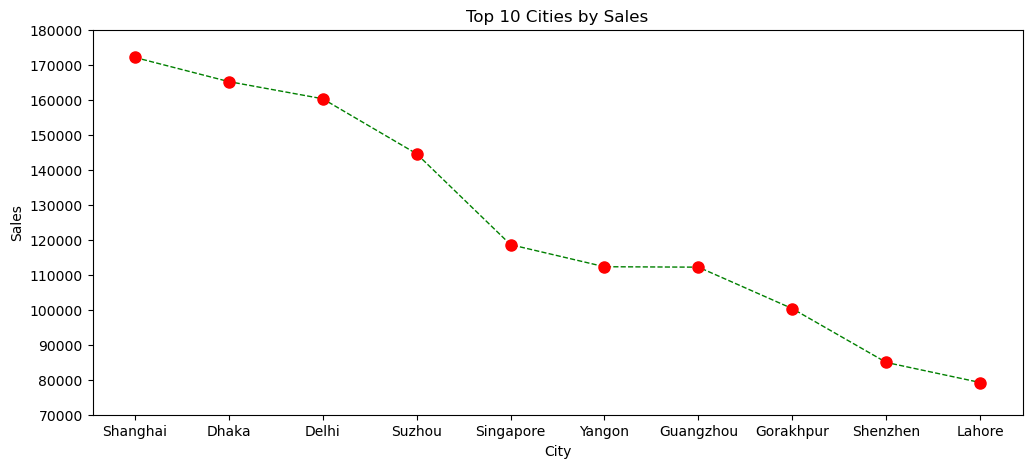

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'g--o', mec = 'r', mfc = 'r', ms = 8, lw = 1)
plt.ylim(70000, 180000)
plt.yticks(range(70000, 180001, 10000))
plt.xlabel('City')
plt.ylabel('Sales');

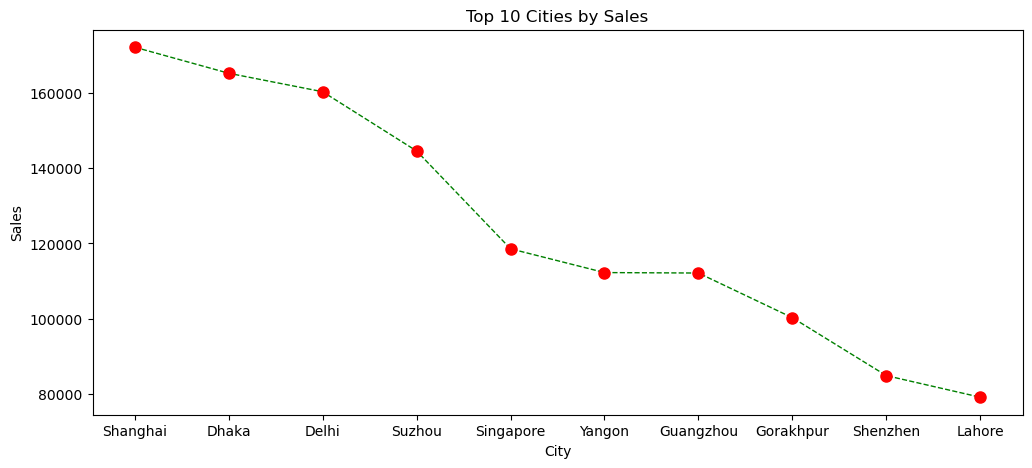

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'g--o', mec = 'r', mfc = 'r', ms = 8, lw = 1)
plt.xlabel('City')
plt.ylabel('Sales')
plt.savefig("Top 10 Cities by Sales.jpg") #.png, .pdf

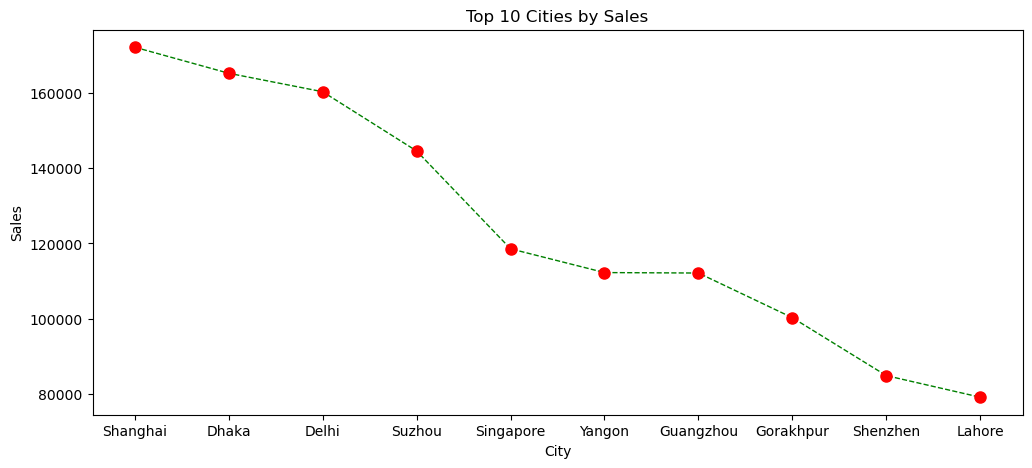

In [ ]:
plt.figure(figsize = (12, 5)) # width, height
plt.title('Top 10 Cities by Sales')
plt.plot(city, sales, 'g--o', mec = 'r', mfc = 'r', ms = 8, lw = 1)
plt.xlabel('City')
plt.ylabel('Sales')
plt.savefig("Top 10 Cities by Sales.jpg", dpi = 500) #.png, .pdf

In [ ]:
weight = [10,14, 12, 15, 17]
height = [90, 88, 91, 100, 115]
calories = [10, 15, 25, 14, 30]

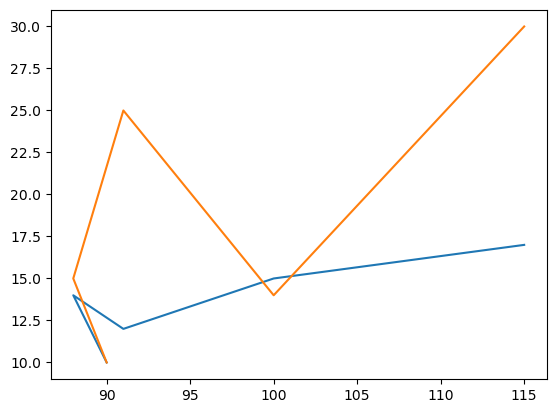

In [ ]:
plt.plot(height, weight)
plt.plot(height, calories);

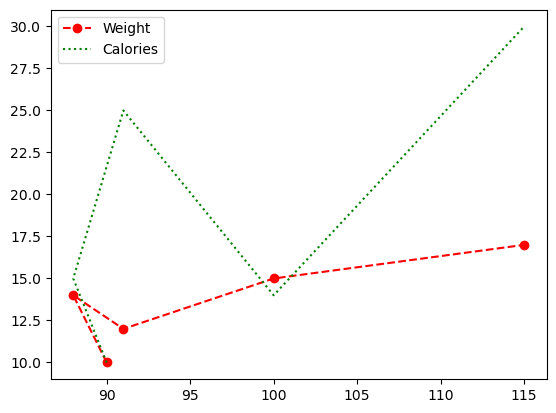

In [ ]:
plt.plot(height, weight, 'r--o')
plt.plot(height, calories, 'g:')
plt.legend(labels = ['Weight', 'Calories']);

In [ ]:
print(plt.plot.__doc__)

Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yield identical results:

>>> plot(x, y, 'go--', linewidth=2, markersize=12)
>>> plot(x, y, color='green', marker='o', linestyle='dashed',
...      linewidth=2, markersize=12)


# Vertical Bar Chart

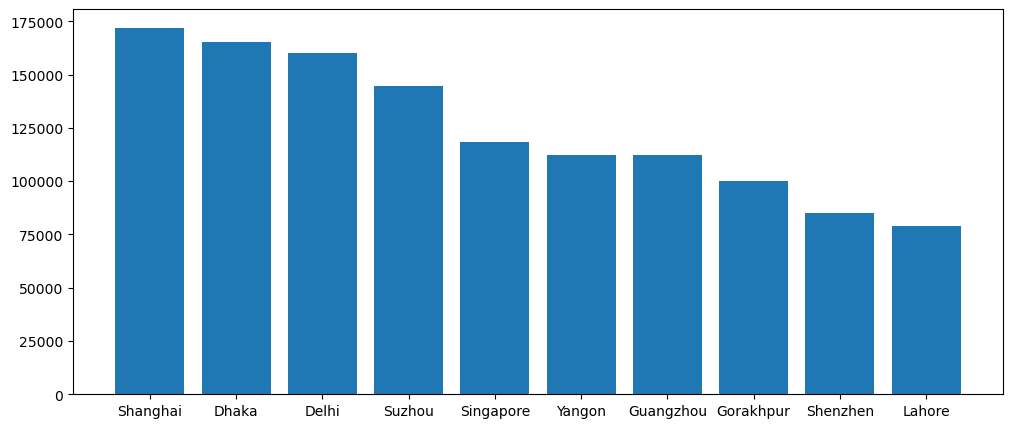

In [ ]:
plt.figure(figsize = (12, 5))
plt.bar(city, sales);

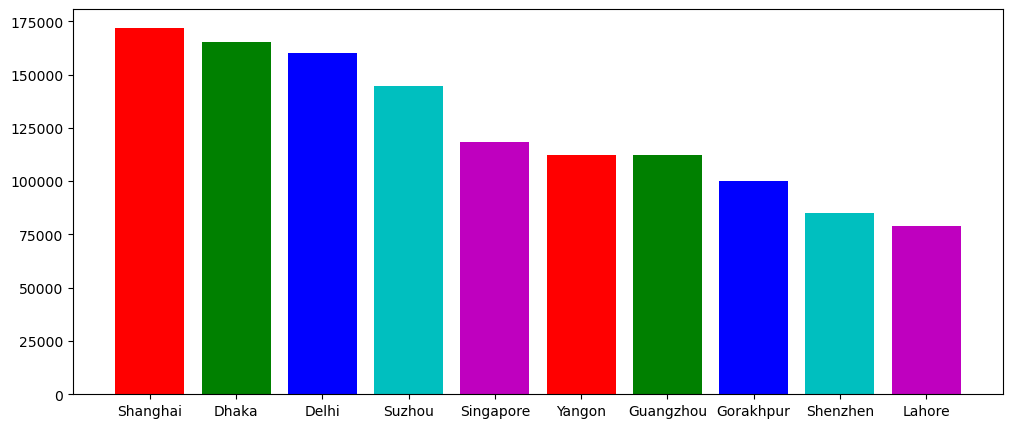

In [ ]:
plt.figure(figsize = (12, 5))
plt.bar(city, sales, color = ['r', 'g', 'b', 'c', 'm']*2);

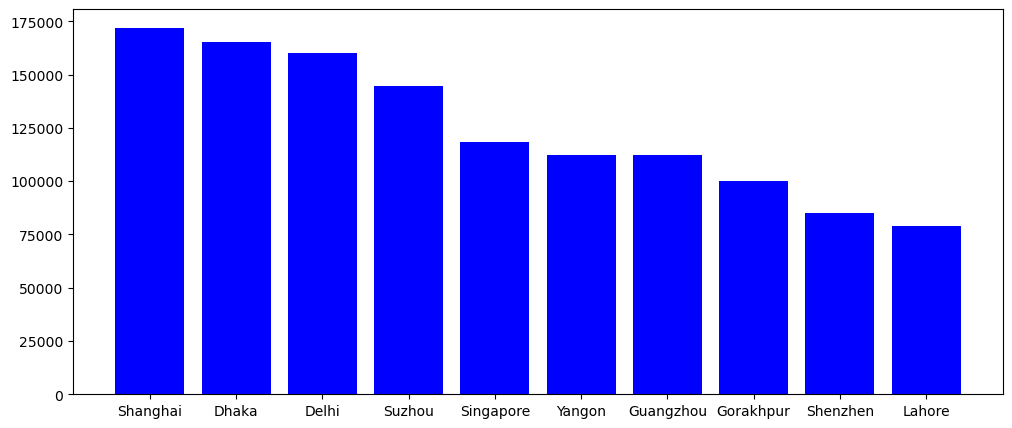

In [ ]:
plt.figure(figsize = (12, 5))
plt.bar(city, sales, color = ['b']*10);

# Horizontal Bar Chart

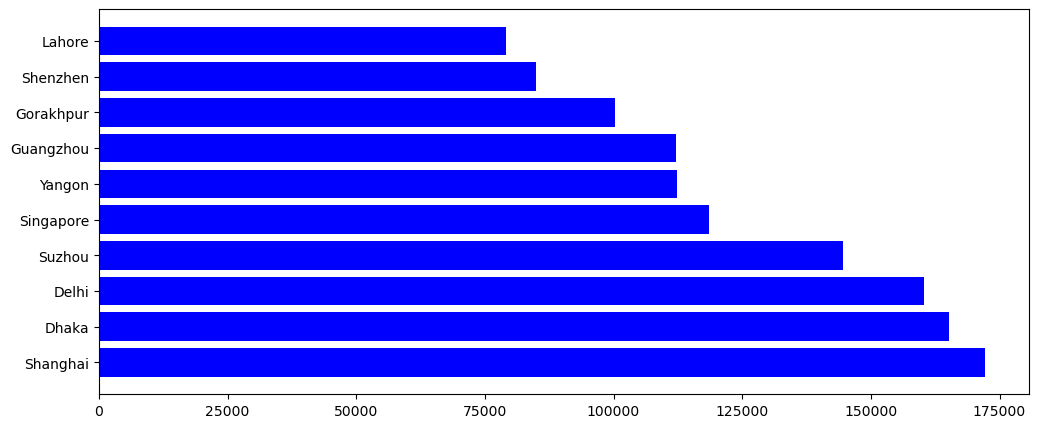

In [ ]:
plt.figure(figsize = (12, 5))
plt.barh(city, sales, color = ['b']*10);

# Histogram

In [ ]:
df.columns

Index(['Order Date', 'Order Priority', 'Ship Type', 'City', 'State', 'Country',
       'Region', 'Segment', 'Super Category', 'Category', 'Price',
       'Operational/ Production Cost', 'Selling Price', 'Discount',
       'Shipping Cost', 'Sales', 'Profit', 'Quantity'],
      dtype='object')

In [ ]:
df['Sales'].describe()

count     6428.000000
mean       865.233384
std       2639.154865
min          4.529412
25%         80.333333
50%        140.441176
75%        391.028056
max      42854.863900
Name: Sales, dtype: float64

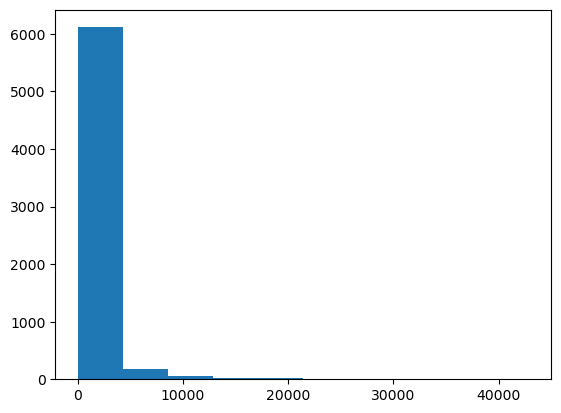

In [ ]:
plt.hist(df['Sales']);

In [ ]:
np.linspace(df['Sales'].min(), df['Sales'].max(), 12)

array([4.52941176e+00, 3.90001437e+03, 7.79549932e+03, 1.16909843e+04,
       1.55864692e+04, 1.94819542e+04, 2.33774391e+04, 2.72729241e+04,
       3.11684090e+04, 3.50638940e+04, 3.89593789e+04, 4.28548639e+04])

,Sales
9,79200.81
8,84935.70
7,100305.08
6,112161.36
5,112282.65
4,118592.30
3,144554.44
2,160275.32
1,165180.44
0,172090.21


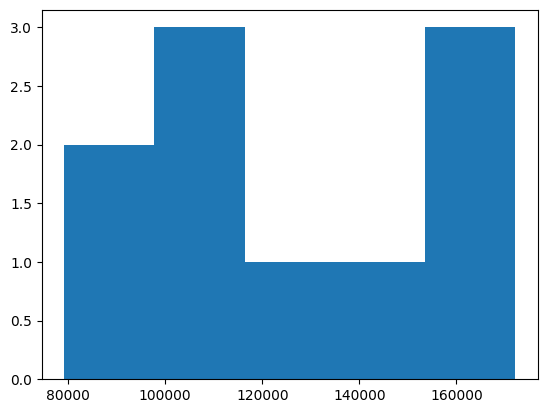

In [ ]:
plt.hist(sales, bins=5);
sales.sort_values(ascending=True)

In [ ]:
np.linspace(df['Sales'].min(), df['Sales'].max(), 6)

array([4.52941176e+00, 8.57459631e+03, 1.71446632e+04, 2.57147301e+04,
       3.42847970e+04, 4.28548639e+04])

# Scatter Plot

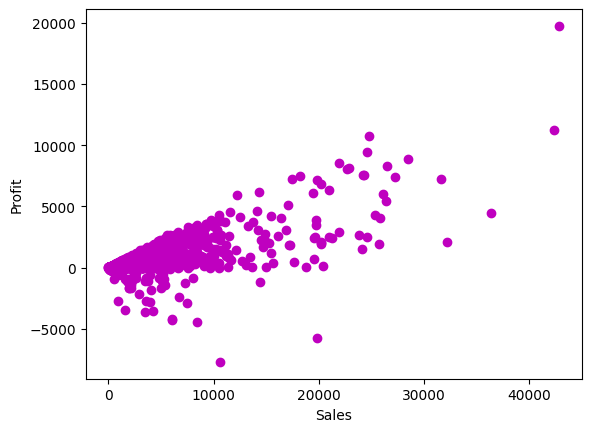

In [ ]:
plt.scatter(df['Sales'], df['Profit'], color = 'm')
plt.xlabel("Sales")
plt.ylabel("Profit");

In [ ]:
# df.apply(lambda c: c.name, axis=0)
# np.sum(np.array([[2,3],[4,5]]), axis=1)

array([5, 9])

# Bubble Plot

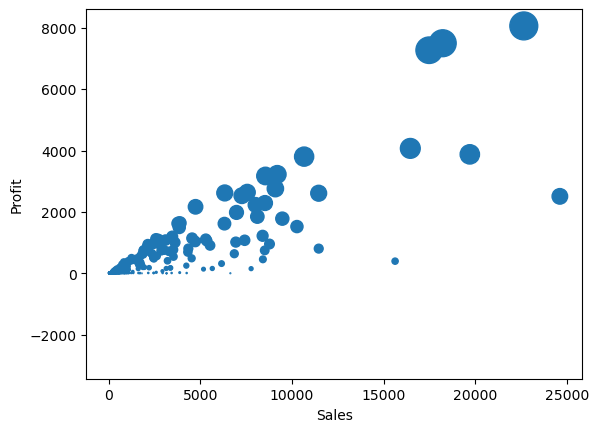

In [ ]:
plt.scatter(df['Sales'][:1000], df['Profit'][:1000], s = df['Profit'][:1000]*0.05)
plt.xlabel("Sales")
plt.ylabel("Profit");

# Boxplot

In [ ]:
df['Sales'].describe()

count     6428.000000
mean       865.233384
std       2639.154865
min          4.529412
25%         80.333333
50%        140.441176
75%        391.028056
max      42854.863900
Name: Sales, dtype: float64

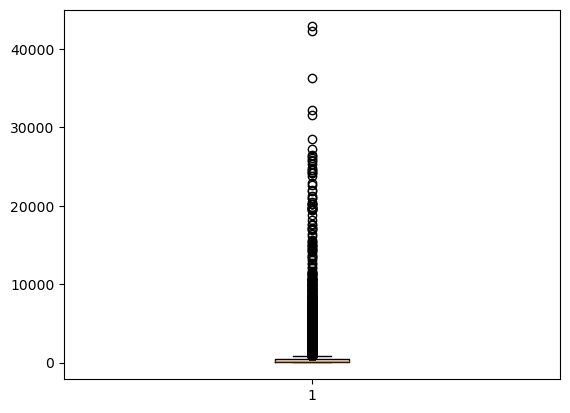

In [ ]:
plt.boxplot(df['Sales']);

In [ ]:
weight

[10, 14, 12, 15, 17]

In [ ]:
nums = [-20,1,2,3,4,5,20]
nums

[-20, 1, 2, 3, 4, 5, 20]

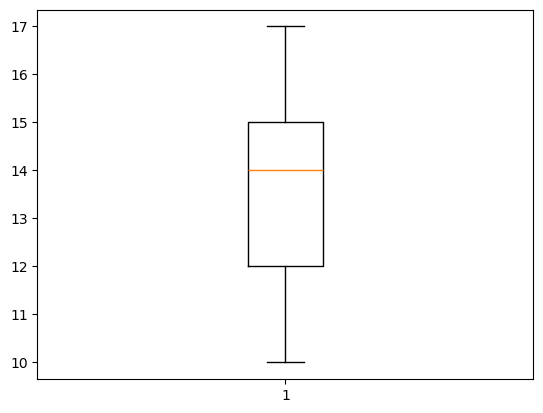

In [ ]:
plt.boxplot(weight); # to idetify outlayers

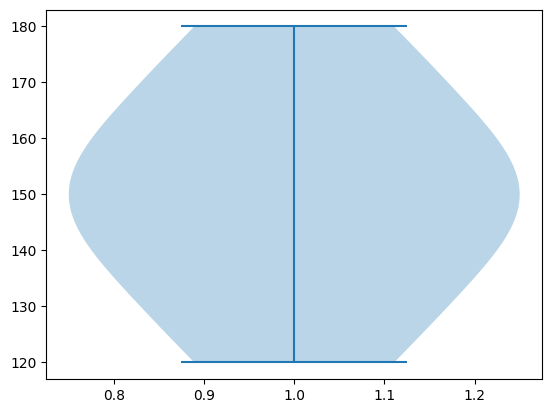

In [ ]:
# plt.violinplot(sales)
import matplotlib.pyplot as plt
import pandas as pd

# Example sales data (Series with 9 values)
sales = pd.Series([120, 150, 170, 180, 160, 130, 140, 145, 155])

# Create the violin plot
plt.violinplot(sales)

# Show the plot
plt.show()


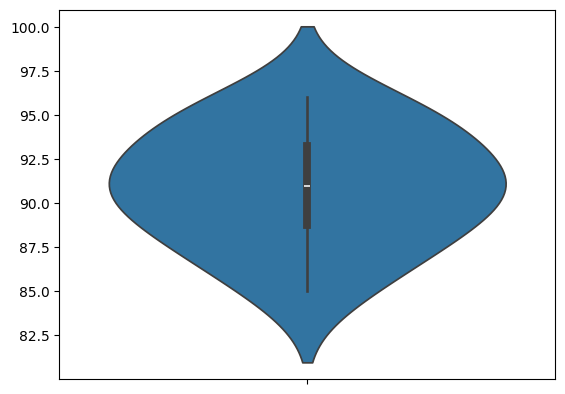

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example data: test scores for a single class
data = [85, 90, 92, 88, 95, 91, 87, 93, 94, 96, 89, 91]

# Create a violin plot (single group)
sns.violinplot(data=data)

plt.show()


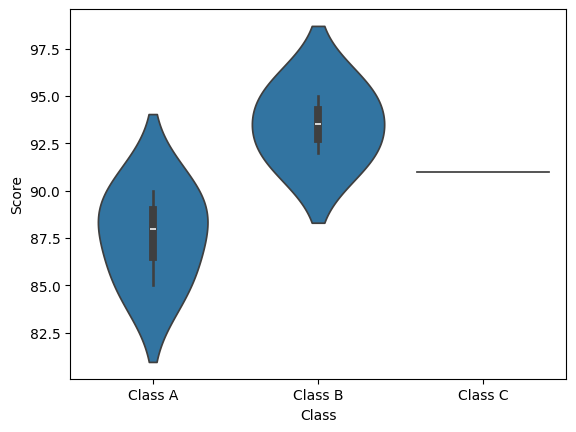

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example data: test scores by class
data = {
    "Class": ["Class A", "Class A", "Class A", "Class B", "Class B", "Class C"],
    "Score": [85, 90, 88, 92, 95, 91]
}

# Create a violin plot for multiple categories
sns.violinplot(x="Class", y="Score", data=data)

plt.show()


In [ ]:
np.ones((3,2))

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

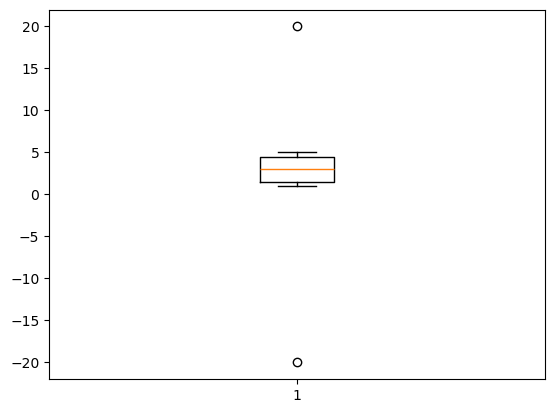

In [ ]:
plt.boxplot(nums);